In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier

In [17]:
data = pd.read_csv("smart_grid_stability_augmented.csv")

print("Dataset Shape:", data.shape)
print(data.head())

Dataset Shape: (60000, 14)
       tau1      tau2      tau3      tau4        p1        p2        p3  \
0  2.959060  3.079885  8.381025  9.780754  3.763085 -0.782604 -1.257395   
1  9.304097  4.902524  3.047541  1.369357  5.067812 -1.940058 -1.872742   
2  8.971707  8.848428  3.046479  1.214518  3.405158 -1.207456 -1.277210   
3  0.716415  7.669600  4.486641  2.340563  3.963791 -1.027473 -1.938944   
4  3.134112  7.608772  4.943759  9.857573  3.525811 -1.125531 -1.845975   

         p4        g1        g2        g3        g4      stab     stabf  
0 -1.723086  0.650456  0.859578  0.887445  0.958034  0.055347  unstable  
1 -1.255012  0.413441  0.862414  0.562139  0.781760 -0.005957    stable  
2 -0.920492  0.163041  0.766689  0.839444  0.109853  0.003471  unstable  
3 -0.997374  0.446209  0.976744  0.929381  0.362718  0.028871  unstable  
4 -0.554305  0.797110  0.455450  0.656947  0.820923  0.049860  unstable  


In [30]:
data["stabf"] = data["stabf"].replace({"stable":1,"unstable":0}).astype(int)

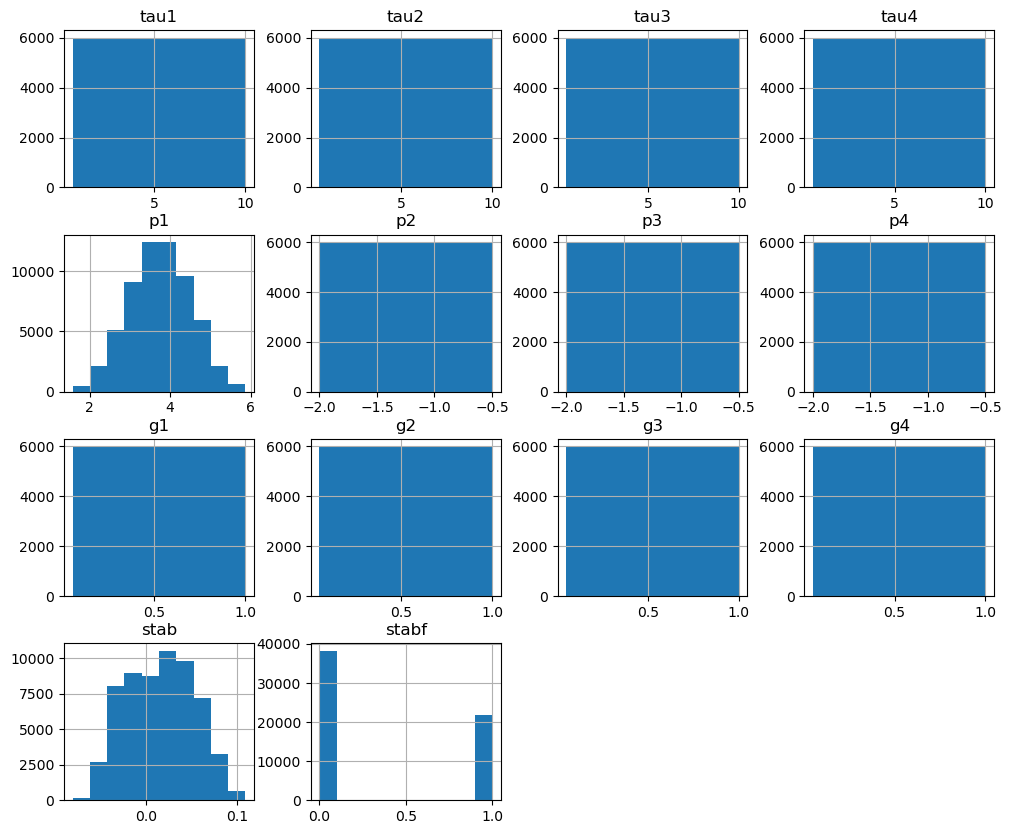

In [31]:
data.hist(figsize=(12,10))
plt.show()

In [20]:
X = data.drop(["stab","stabf"], axis=1)
y = data["stabf"]

In [29]:
y = y.map({"stable":1, "unstable":0})

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)


In [23]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Bagging": BaggingClassifier(),
    "Extra Trees": ExtraTreesClassifier()

}

accuracy_scores = {}

for name,model in models.items():

    model.fit(X_train,y_train)

    prediction = model.predict(X_test)

    acc = accuracy_score(y_test,prediction)

    accuracy_scores[name] = acc

    print("Model:",name)
    print("Accuracy:",acc)
    print(classification_report(y_test,prediction))
    print("-----------------------------------")

Model: Logistic Regression
Accuracy: 0.8100833333333334
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      7678
           1       0.76      0.69      0.72      4322

    accuracy                           0.81     12000
   macro avg       0.80      0.78      0.79     12000
weighted avg       0.81      0.81      0.81     12000

-----------------------------------
Model: Decision Tree
Accuracy: 0.8973333333333333
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      7678
           1       0.86      0.86      0.86      4322

    accuracy                           0.90     12000
   macro avg       0.89      0.89      0.89     12000
weighted avg       0.90      0.90      0.90     12000

-----------------------------------
Model: Random Forest
Accuracy: 0.9494166666666667
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7678
         

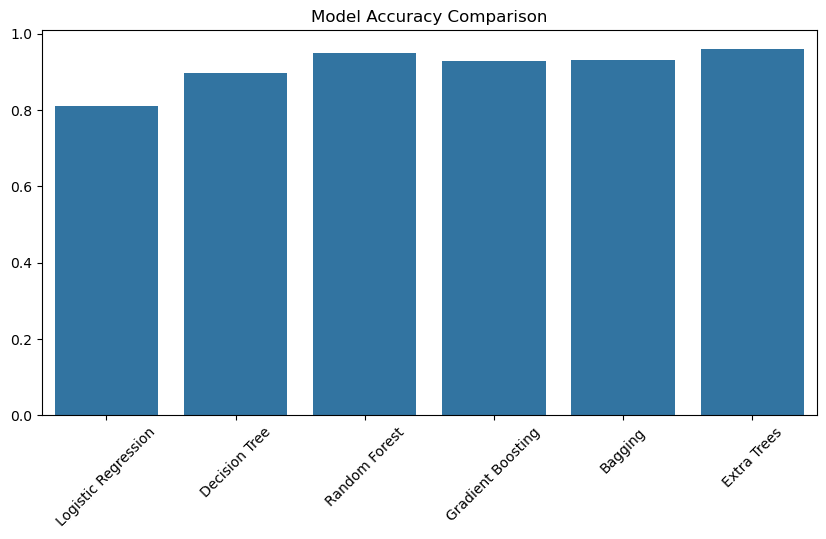

In [24]:
names = list(accuracy_scores.keys())
values = list(accuracy_scores.values())

plt.figure(figsize=(10,5))
sns.barplot(x=names,y=values)
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.show()


In [25]:
best_model_name = max(accuracy_scores,key=accuracy_scores.get)

print("Best Model:",best_model_name)

best_model = models[best_model_name]

Best Model: Extra Trees


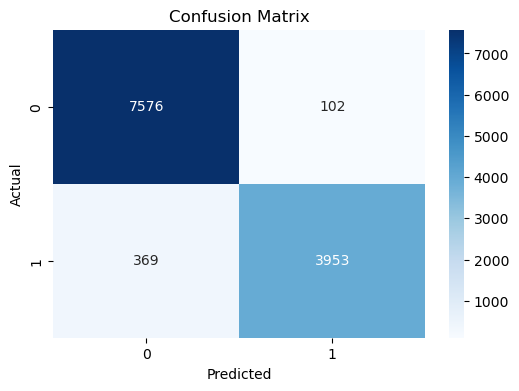

In [26]:
pred = best_model.predict(X_test)

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
with open("smart_grid_model.pkl","wb") as f:
    pickle.dump(best_model,f)

print("Model saved successfully")

Model saved successfully
